# Notebook: `02_eda.ipynb`

**Mục tiêu:** Thực hiện phân tích thống kê chuỗi thời gian nâng cao trên bộ dữ liệu nhu cầu điện năng quốc gia Vương quốc Anh đã làm sạch (`uk_electricity_cleaned.csv`). Notebook này tập trung xây dựng nền tảng toán học gồm tính dừng, tự tương quan, phân rã tín hiệu và tương quan chéo đa biến, nhằm định hướng cho bước xây dựng đặc trưng và mô hình hóa ở notebook tiếp theo, đúng với chuỗi logic đã trình bày trong đề xuất nghiên cứu cập nhật *"Dự Báo Nhu Cầu Điện Năng Quốc Gia Vương Quốc Anh Theo Chu Kỳ Quyết Toán Bằng Học Máy Dựa Trên Đặc Trưng Thời Gian Tuần Hoàn"*, phiên bản so sánh sáu mô hình: hai đường cơ sở mùa vụ ngây thơ **SNaive Daily** ($\hat{Y}_t = Y_{t-48}$) và **SNaive Weekly** ($\hat{Y}_t = Y_{t-336}$), cùng với Linear Regression, Random Forest, XGBoost và LightGBM.

**Chuỗi phân tích:**

**B1:** Data Ingestion and Indexing, nạp dữ liệu sạch và dựng trục thời gian liên tục 30 phút.

**B2:** Stationarity Testing, kiểm định tính dừng bằng kiểm định Augmented Dickey Fuller.

**B3:** Autocorrelation Analysis, khảo sát hàm tự tương quan ACF và tự tương quan riêng phần PACF nhằm định lượng chính xác độ trễ 48 (ngày) và độ trễ 336 (tuần), hai mốc thời gian sẽ trở thành công thức của hai đường cơ sở SNaive Daily và SNaive Weekly ở notebook huấn luyện mô hình.

**B4:** Time Series Signal Decomposition, phân rã tín hiệu nhu cầu điện thành thành phần xu hướng, mùa vụ và phần dư bằng phương pháp STL đa mùa vụ.

**B5:** Multivariate Correlation Mapping, phân tích tương tác giữa nhu cầu điện và sản lượng năng lượng tái tạo nhúng.


### Thiết lập môi trường

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import MSTL

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")
# SỬA: tăng cỡ chữ chung. Chữ mặc định matplotlib quá nhỏ, khi hình bị co lại
# để nhét vào khổ giấy LNCS thì gần như không đọc được.
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "axes.titleweight": "normal",   # title không bold nữa, đỡ rối
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.figsize": (14, 5),
})

# Số chu kỳ quyết toán 30 phút trong một ngày và trong một tuần, dùng xuyên suốt notebook
CHU_KY_MOT_NGAY = 48
CHU_KY_MOT_TUAN = 48 * 7

## Part 1: Thu thập và lập chỉ mục dữ liệu

### 1.1 Nạp dữ liệu sạch

In [2]:
df_raw = pd.read_csv("uk_electricity_cleaned.csv")
df_raw["SETTLEMENT_DATE"] = pd.to_datetime(df_raw["SETTLEMENT_DATE"])
df_raw = df_raw.sort_values(["SETTLEMENT_DATE", "SETTLEMENT_PERIOD"]).reset_index(drop=True)

print(f"Số dòng: {df_raw.shape[0]:,} | Số cột: {df_raw.shape[1]}")
print(f"Giai đoạn: {df_raw['SETTLEMENT_DATE'].min().date()} đến {df_raw['SETTLEMENT_DATE'].max().date()}")
df_raw.head()

Số dòng: 105,216 | Số cột: 22
Giai đoạn: 2020-01-01 đến 2025-12-31


,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,PUMP_STORAGE_PUMPING,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,SETTLEMENT_DATE,SOURCE_FILE_YEAR
0,1,"26,340.0000","27,153.0000","23,821.0000","1,073.0000","6,465.0000",0.0000,"13,040.0000",0.0000,15.0000,"1,703.0000",0.0000,852.0000,-151.0000,-47.0000,854.0000,0.0000,0.0000,0.0000,0.0000,2020-01-01,2020
1,2,"26,921.0000","27,684.0000","24,393.0000","1,020.0000","6,465.0000",0.0000,"13,040.0000",0.0000,17.0000,"1,703.0000",0.0000,853.0000,-146.0000,0.0000,854.0000,0.0000,0.0000,0.0000,0.0000,2020-01-01,2020
2,3,"26,569.0000","27,240.0000","24,085.0000","1,010.0000","6,465.0000",0.0000,"13,040.0000",0.0000,18.0000,"1,703.0000",0.0000,852.0000,-53.0000,0.0000,854.0000,0.0000,0.0000,0.0000,0.0000,2020-01-01,2020
3,4,"25,754.0000","26,435.0000","23,350.0000","1,043.0000","6,465.0000",0.0000,"13,040.0000",0.0000,15.0000,"1,703.0000",0.0000,852.0000,-66.0000,0.0000,854.0000,0.0000,0.0000,0.0000,0.0000,2020-01-01,2020
4,5,"25,075.0000","25,824.0000","22,788.0000","1,001.0000","6,465.0000",0.0000,"13,040.0000",0.0000,15.0000,"1,704.0000",0.0000,853.0000,-74.0000,-60.0000,854.0000,0.0000,0.0000,0.0000,0.0000,2020-01-01,2020


### 1.2 Xây dựng trục thời gian liên tục

Mỗi chu kỳ quyết toán kéo dài 30 phút, được đánh số từ 1 đến 48 trong một ngày. Mốc thời gian cụ thể của từng quan trắc được suy ra bằng cách cộng thêm vào ngày quyết toán số phút tương ứng với vị trí chu kỳ, sau đó được thiết lập làm chỉ mục DatetimeIndex với tần suất cố định 30 phút, phục vụ trực tiếp cho các phép toán chuỗi thời gian ở các bước tiếp theo như kiểm định tính dừng, tính tự tương quan và phân rã tín hiệu.

In [3]:
df = df_raw.copy()
df["DATETIME"] = df["SETTLEMENT_DATE"] + pd.to_timedelta((df["SETTLEMENT_PERIOD"] - 1) * 30, unit="m")
df = df.set_index("DATETIME").sort_index()

# Ép tần suất 30 phút cố định; nếu tồn tại khoảng trống trên trục thời gian, asfreq sẽ tạo dòng NaN tương ứng
df = df.asfreq("30min")

so_dong_trong = df["ND"].isna().sum()
print(f"Tần suất chỉ mục: {df.index.freq}")
print(f"Số dòng sau khi ép trục thời gian liên tục: {df.shape[0]:,}")
print(f"Số dòng trống phát sinh do thiếu mốc thời gian: {so_dong_trong}")
df[["SETTLEMENT_PERIOD", "ND", "TSD", "ENGLAND_WALES_DEMAND"]].head()

Tần suất chỉ mục: <30 * Minutes>
Số dòng sau khi ép trục thời gian liên tục: 105,216
Số dòng trống phát sinh do thiếu mốc thời gian: 0


,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND
DATETIME,,,,
2020-01-01 00:00:00,1,"26,340.0000","27,153.0000","23,821.0000"
2020-01-01 00:30:00,2,"26,921.0000","27,684.0000","24,393.0000"
2020-01-01 01:00:00,3,"26,569.0000","27,240.0000","24,085.0000"
2020-01-01 01:30:00,4,"25,754.0000","26,435.0000","23,350.0000"
2020-01-01 02:00:00,5,"25,075.0000","25,824.0000","22,788.0000"


**Nhận xét**

Sau khi ép trục thời gian về tần suất 30 phút cố định, số dòng dữ liệu không đổi và không phát sinh thêm dòng trống nào, xác nhận trục thời gian của dữ liệu đã làm sạch ở notebook trước liên tục tuyệt đối trên toàn bộ giai đoạn từ năm 2020 đến năm 2025, không còn khoảng trống hay chu kỳ trùng lặp. Đây là điều kiện tiên quyết bắt buộc để các phương pháp thống kê chuỗi thời gian ở các bước tiếp theo, vốn giả định khoảng cách đều đặn giữa các quan trắc liên tiếp, cho ra kết quả đáng tin cậy.

## Part 2: Kiểm tra tính ổn định

### 2.1 Kiểm định Augmented Dickey Fuller trên chuỗi gốc

Kiểm định ADF có giả thuyết gốc H0 cho rằng chuỗi tồn tại nghiệm đơn vị, tức không dừng, và giả thuyết đối H1 cho rằng chuỗi có tính dừng. Giá trị p nhỏ hơn ngưỡng ý nghĩa 0,05 cho phép bác bỏ H0 và kết luận chuỗi có tính dừng.

In [4]:
def kiem_dinh_adf(chuoi, ten_chuoi):
    ket_qua = adfuller(chuoi.dropna(), autolag="AIC")
    thong_ke = {
        "Chuỗi": ten_chuoi,
        "Thống kê ADF": ket_qua[0],
        "Giá trị p": ket_qua[1],
        "Số độ trễ sử dụng": ket_qua[2],
        "Số quan trắc": ket_qua[3],
        "Giá trị tới hạn 1%": ket_qua[4]["1%"],
        "Giá trị tới hạn 5%": ket_qua[4]["5%"],
        "Kết luận": "Dừng" if ket_qua[1] < 0.05 else "Không dừng",
    }
    return thong_ke

cac_chuoi_can_kiem_dinh = ["ND", "TSD", "ENGLAND_WALES_DEMAND"]
ket_qua_adf_goc = pd.DataFrame([kiem_dinh_adf(df[c], c) for c in cac_chuoi_can_kiem_dinh])
ket_qua_adf_goc

,Chuỗi,Thống kê ADF,Giá trị p,Số độ trễ sử dụng,Số quan trắc,Giá trị tới hạn 1%,Giá trị tới hạn 5%,Kết luận
0,ND,-14.1875,0.0000,69,105146,-3.4304,-2.8616,Dừng
1,TSD,-15.1984,0.0000,67,105148,-3.4304,-2.8616,Dừng
2,ENGLAND_WALES_DEMAND,-13.6185,0.0000,69,105146,-3.4304,-2.8616,Dừng


**Nhận xét**

Cả ba chuỗi nhu cầu điện lõi đều bác bỏ giả thuyết H0 với giá trị p rất nhỏ, cho thấy chuỗi ở dạng mức gốc đã mang tính dừng theo kiểm định ADF, mặc dù chuỗi thể hiện tính mùa vụ mạnh theo ngày, theo tuần và theo năm quan sát được ở notebook trước. Kết quả này không mâu thuẫn với sự hiện diện của mùa vụ, vì kiểm định ADF chỉ kiểm tra sự tồn tại của nghiệm đơn vị mang bản chất ngẫu nhiên bước đi ngẫu nhiên, trong khi tính mùa vụ là một thành phần tất định lặp lại đều đặn, không làm phương sai của chuỗi tăng dần theo thời gian. Do chuỗi đã dừng ở mức gốc, các mô hình được đề xuất trong Research Proposal như Random Forest, XGBoost và LightGBM có thể sử dụng trực tiếp giá trị ND làm biến mục tiêu mà không bắt buộc phải lấy sai phân trước khi đưa vào huấn luyện.

### 2.2 Kiểm định trên chuỗi sai phân bậc một

Nhằm đối chiếu và củng cố kết luận ở mục 2.1, kiểm định ADF được lặp lại trên chuỗi sai phân bậc một của ND, tức hiệu số giữa hai chu kỳ quyết toán liên tiếp, đại diện cho tốc độ thay đổi nhu cầu điện giữa hai lần đo cách nhau 30 phút.

In [5]:
chuoi_sai_phan = df["ND"].diff().dropna()
ket_qua_adf_sai_phan = pd.DataFrame([kiem_dinh_adf(chuoi_sai_phan, "ND (sai phân bậc một)")])
ket_qua_adf_sai_phan

,Chuỗi,Thống kê ADF,Giá trị p,Số độ trễ sử dụng,Số quan trắc,Giá trị tới hạn 1%,Giá trị tới hạn 5%,Kết luận
0,ND (sai phân bậc một),-39.0927,0.0000,69,105145,-3.4304,-2.8616,Dừng


**Nhận xét**

Chuỗi sai phân bậc một của ND cho thống kê ADF càng âm hơn và giá trị p càng nhỏ hơn so với chuỗi gốc, khẳng định chuỗi sai phân dừng với mức độ tin cậy còn cao hơn. Kết quả này phù hợp về mặt lý thuyết, vì việc lấy sai phân thường làm tăng cường tính dừng của một chuỗi vốn đã dừng ở mức gốc. Tuy nhiên do mục 2.1 đã xác nhận ND dừng ở mức gốc, notebook giữ nguyên đơn vị MW của ND xuyên suốt các bước phân tích tiếp theo và không sử dụng chuỗi sai phân làm biến mục tiêu chính thức của mô hình.

# Part 3: Phân tích tự tương quan (ACF AND PACF)

### 3.1 Hàm tự tương quan ACF trên độ trễ ngắn hạn

Hàm tự tương quan ACF đo mức độ tương quan giữa giá trị nhu cầu điện tại thời điểm hiện tại với giá trị của chính nó tại các độ trễ trước đó. Đồ thị dưới đây khảo sát 240 độ trễ đầu tiên, tương ứng năm ngày liên tiếp, nhằm làm nổi bật chu kỳ ngày đêm của nhu cầu điện.

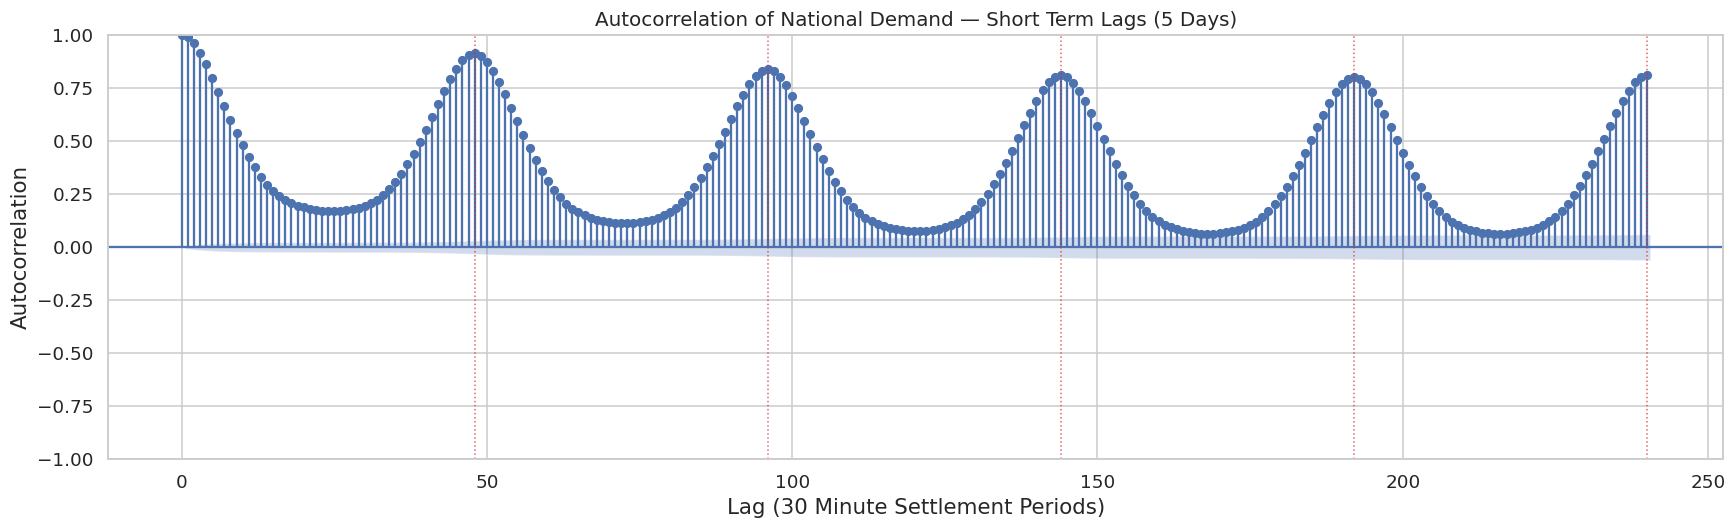

In [6]:
so_do_tre_ngan = 240  # 5 ngày, mỗi ngày 48 chu kỳ

fig, ax = plt.subplots(figsize=(16, 5))
plot_acf(df["ND"], lags=so_do_tre_ngan, ax=ax, title="")
for boi_so in range(1, so_do_tre_ngan // CHU_KY_MOT_NGAY + 1):
    ax.axvline(boi_so * CHU_KY_MOT_NGAY, color="tab:red", linestyle=":", linewidth=1, alpha=0.7)
ax.set_title("Autocorrelation of National Demand \u2014 Short Term Lags (5 Days)", fontsize=13)
ax.set_xlabel("Lag (30 Minute Settlement Periods)")
ax.set_ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

**Nhận xét**

Đồ thị ACF thể hiện dạng sóng lặp lại rõ rệt với chu kỳ đúng 48 độ trễ, khớp chính xác với số chu kỳ quyết toán trong một ngày. Các đường kẻ đỏ đứt nét đánh dấu bội số của 48 đều rơi đúng vào các đỉnh cục bộ của hàm tự tương quan, xác nhận nhu cầu điện tại một thời điểm bất kỳ tương quan mạnh nhất với giá trị của chính nó vào cùng một khung giờ của các ngày trước đó. Biên độ của các đỉnh giảm dần rất chậm theo thời gian, cho thấy tính bền vững cao của quy luật chu kỳ ngày đêm trong toàn bộ khoảng khảo sát năm ngày. Đây chính là bằng chứng định lượng trực tiếp biện minh cho đường cơ sở **SNaive Daily** ($\hat{Y}_t = Y_{t-48}$) được đề xuất trong đề xuất nghiên cứu: nếu tương quan tại độ trễ 48 đã cao đến vậy, một phép ngoại suy đơn giản lấy đúng giá trị của 48 chu kỳ trước làm dự báo hôm nay đã có thể nắm bắt phần lớn quán tính thời tiết và nhịp sinh hoạt ngắn hạn, và mọi mô hình phức tạp hơn phải vượt qua được mốc sàn này mới chứng minh được giá trị thực tiễn.


### 3.2 Hàm tự tương quan ACF trên độ trễ dài hạn

Đồ thị tiếp theo mở rộng phạm vi khảo sát lên 672 độ trễ, tương ứng hai tuần liên tiếp, nhằm kiểm tra sự tồn tại của chu kỳ tuần bên cạnh chu kỳ ngày đã phát hiện ở mục 3.1.

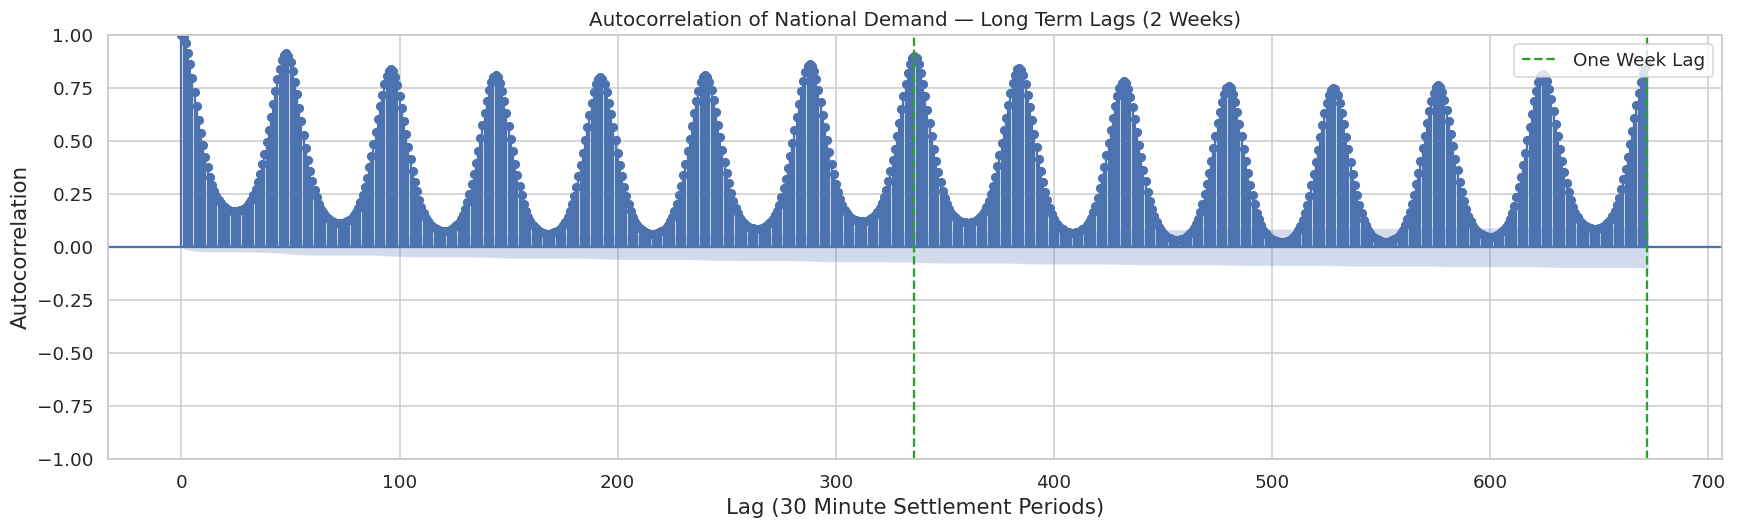

In [7]:
so_do_tre_dai = CHU_KY_MOT_TUAN * 2  # 2 tuần

fig, ax = plt.subplots(figsize=(16, 5))
plot_acf(df["ND"], lags=so_do_tre_dai, ax=ax, title="")
ax.axvline(CHU_KY_MOT_TUAN, color="tab:green", linestyle="--", linewidth=1.5, label="One Week Lag")
ax.axvline(CHU_KY_MOT_TUAN * 2, color="tab:green", linestyle="--", linewidth=1.5)
ax.set_title("Autocorrelation of National Demand \u2014 Long Term Lags (2 Weeks)", fontsize=13)
ax.set_xlabel("Lag (30 Minute Settlement Periods)")
ax.set_ylabel("Autocorrelation")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Nhận xét**

Trên phạm vi hai tuần, hàm ACF tiếp tục dao động theo chu kỳ 48 độ trễ như đã phát hiện ở mục 3.1, đồng thời biên độ dao động tại độ trễ 336, tức đúng một tuần, cao hơn rõ rệt so với các đỉnh lân cận không trùng thứ trong tuần. Điều này xác nhận sự tồn tại của một chu kỳ tuần lồng bên trong chu kỳ ngày, phản ánh sự khác biệt giữa nhu cầu điện các ngày trong tuần làm việc so với ngày cuối tuần đã được kiểm định ở giả thuyết H4 của notebook trước. Độ trễ 336 chính là công thức của đường cơ sở **SNaive Weekly** ($\hat{Y}_t = Y_{t-336}$) trong đề xuất nghiên cứu, đại diện cho giả định nhu cầu điện hôm nay giống hệt đúng thứ này của tuần trước, tức đối chiếu sáng Thứ Hai với sáng Thứ Hai tuần trước thay vì với ngày Chủ Nhật nghỉ ngơi liền trước. Phát hiện này là cơ sở định lượng vững chắc cho việc lựa chọn hai chu kỳ mùa vụ 48 và 336 khi thực hiện phân rã tín hiệu bằng MSTL ở Bước 4, đồng thời là căn cứ thống kê cho việc thiết lập đồng thời hai đường cơ sở SNaive Daily và SNaive Weekly thay vì một đường cơ sở trung bình gộp duy nhất ở notebook huấn luyện mô hình.


### 3.3 Hàm tự tương quan riêng phần PACF

Khác với ACF, hàm tự tương quan riêng phần PACF đo mức độ tương quan giữa nhu cầu điện hiện tại với giá trị tại một độ trễ cụ thể, sau khi đã loại bỏ ảnh hưởng gián tiếp truyền qua các độ trễ trung gian. Đồ thị dưới đây khảo sát 96 độ trễ đầu tiên, tương ứng hai ngày liên tiếp.

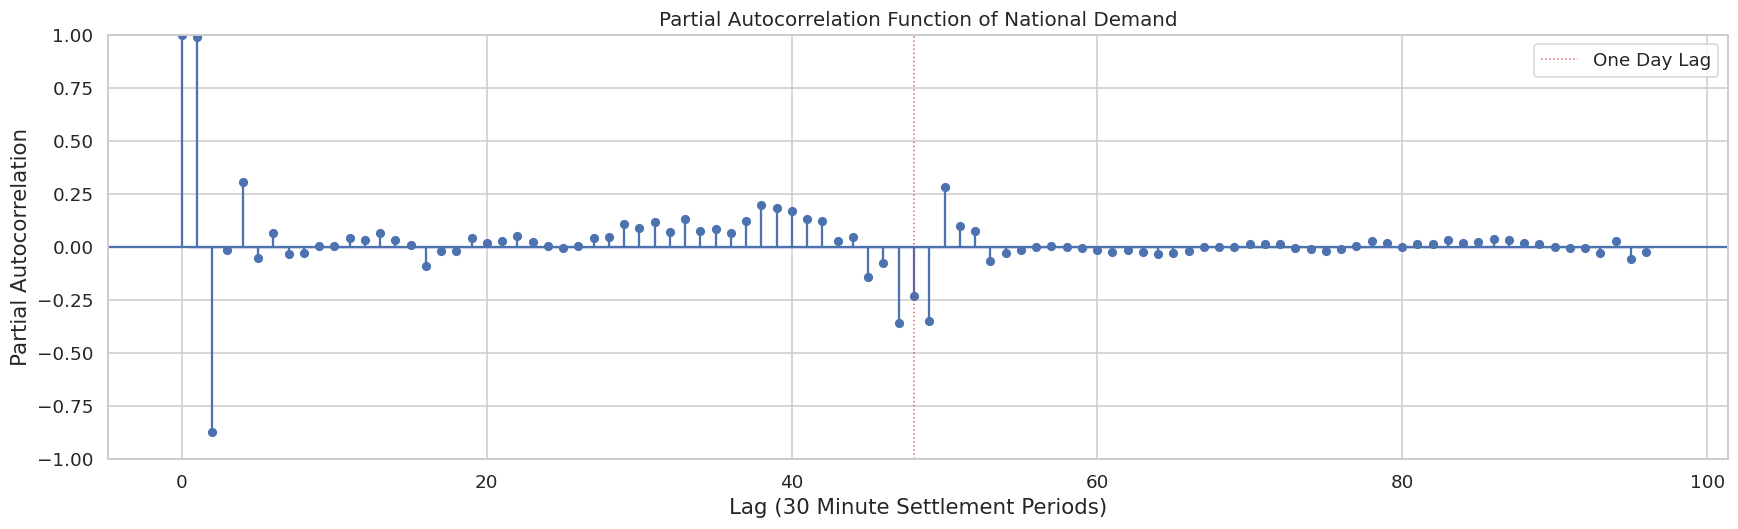

In [8]:
so_do_tre_pacf = 96  # 2 ngày

fig, ax = plt.subplots(figsize=(16, 5))
plot_pacf(df["ND"], lags=so_do_tre_pacf, ax=ax, method="ywm", title="")
ax.axvline(CHU_KY_MOT_NGAY, color="tab:red", linestyle=":", linewidth=1, alpha=0.7, label="One Day Lag")
ax.set_title("Partial Autocorrelation Function of National Demand")
ax.set_xlabel("Lag (30 Minute Settlement Periods)")
ax.set_ylabel("Partial Autocorrelation")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Nhận xét**

Hàm PACF cho thấy các độ trễ đầu tiên, đặc biệt độ trễ 1 và 2, mang giá trị tự tương quan riêng phần rất cao, phản ánh quán tính ngắn hạn mạnh mẽ của nhu cầu điện giữa hai chu kỳ 30 phút liên tiếp. Sau nhóm độ trễ đầu tiên, biên độ PACF giảm nhanh nhưng vẫn xuất hiện một đỉnh đáng chú ý tại độ trễ 48, đúng bằng một ngày, cho thấy phần đóng góp trực tiếp và không thể giải thích gián tiếp qua các độ trễ trung gian của quy luật theo giờ trong ngày. Việc ACF suy giảm chậm trong khi PACF suy giảm nhanh sau vài độ trễ đầu là dấu hiệu điển hình của một quá trình có thành phần tự hồi quy bậc thấp cộng với thành phần mùa vụ mạnh, phù hợp với quyết định trong đề xuất nghiên cứu về việc dùng đặc trưng mã hoá tuần hoàn cùng một tập đặc trưng trễ tự hồi quy được chọn lọc có căn cứ ($H \in \{1,2,12,24,36,48\}$ và $H=336$), thay vì đưa trực tiếp hàng chục độ trễ tự hồi quy vào các mô hình cây. Cùng với các phát hiện ở mục 3.1 và 3.2, ba đồ thị ACF/PACF của bước này xác nhận độc lập rằng độ trễ 48 và độ trễ 336 là hai mốc thời gian có ý nghĩa thống kê mạnh nhất trong toàn bộ chuỗi, đúng bằng công thức của hai đường cơ sở SNaive Daily và SNaive Weekly sẽ được tính toán ở notebook 04.


# Part 4: Phân tích tín hiệu chuỗi thời gian

### 4.1 Phân rã tín hiệu đa mùa vụ bằng MSTL

Kết quả ở Bước 3 xác nhận nhu cầu điện chịu ảnh hưởng đồng thời của hai chu kỳ mùa vụ lồng nhau: chu kỳ ngày với độ dài 48 chu kỳ quyết toán và chu kỳ tuần với độ dài 336 chu kỳ quyết toán. Phương pháp MSTL, tức Multiple Seasonal Trend decomposition using Loess, cho phép phân rã đồng thời cả hai thành phần mùa vụ này cùng với thành phần xu hướng và phần dư, mà không cần biến đổi chuỗi hay lặp lại phân rã STL đơn mùa vụ nhiều lần.

In [9]:
mstl = MSTL(df["ND"], periods=[CHU_KY_MOT_NGAY, CHU_KY_MOT_TUAN])
ket_qua_mstl = mstl.fit()

thanh_phan = pd.DataFrame({
    "trend": ket_qua_mstl.trend,
    "seasonal_daily": ket_qua_mstl.seasonal["seasonal_48"],
    "seasonal_weekly": ket_qua_mstl.seasonal["seasonal_336"],
    "resid": ket_qua_mstl.resid,
})

thanh_phan.head()

,trend,seasonal_daily,seasonal_weekly,resid
DATETIME,,,,
2020-01-01 00:00:00,"29,236.3532","-6,237.8632",979.6599,"2,361.8501"
2020-01-01 00:30:00,"29,247.2646","-5,910.9958","1,157.1990","2,427.5323"
2020-01-01 01:00:00,"29,258.1651","-6,288.2659","1,167.8089","2,431.2919"
2020-01-01 01:30:00,"29,269.0547","-6,988.8405","1,133.6022","2,340.1836"
2020-01-01 02:00:00,"29,279.9333","-7,601.6142","1,196.0291","2,200.6518"


### 4.2 Trực quan hóa các thành phần phân rã

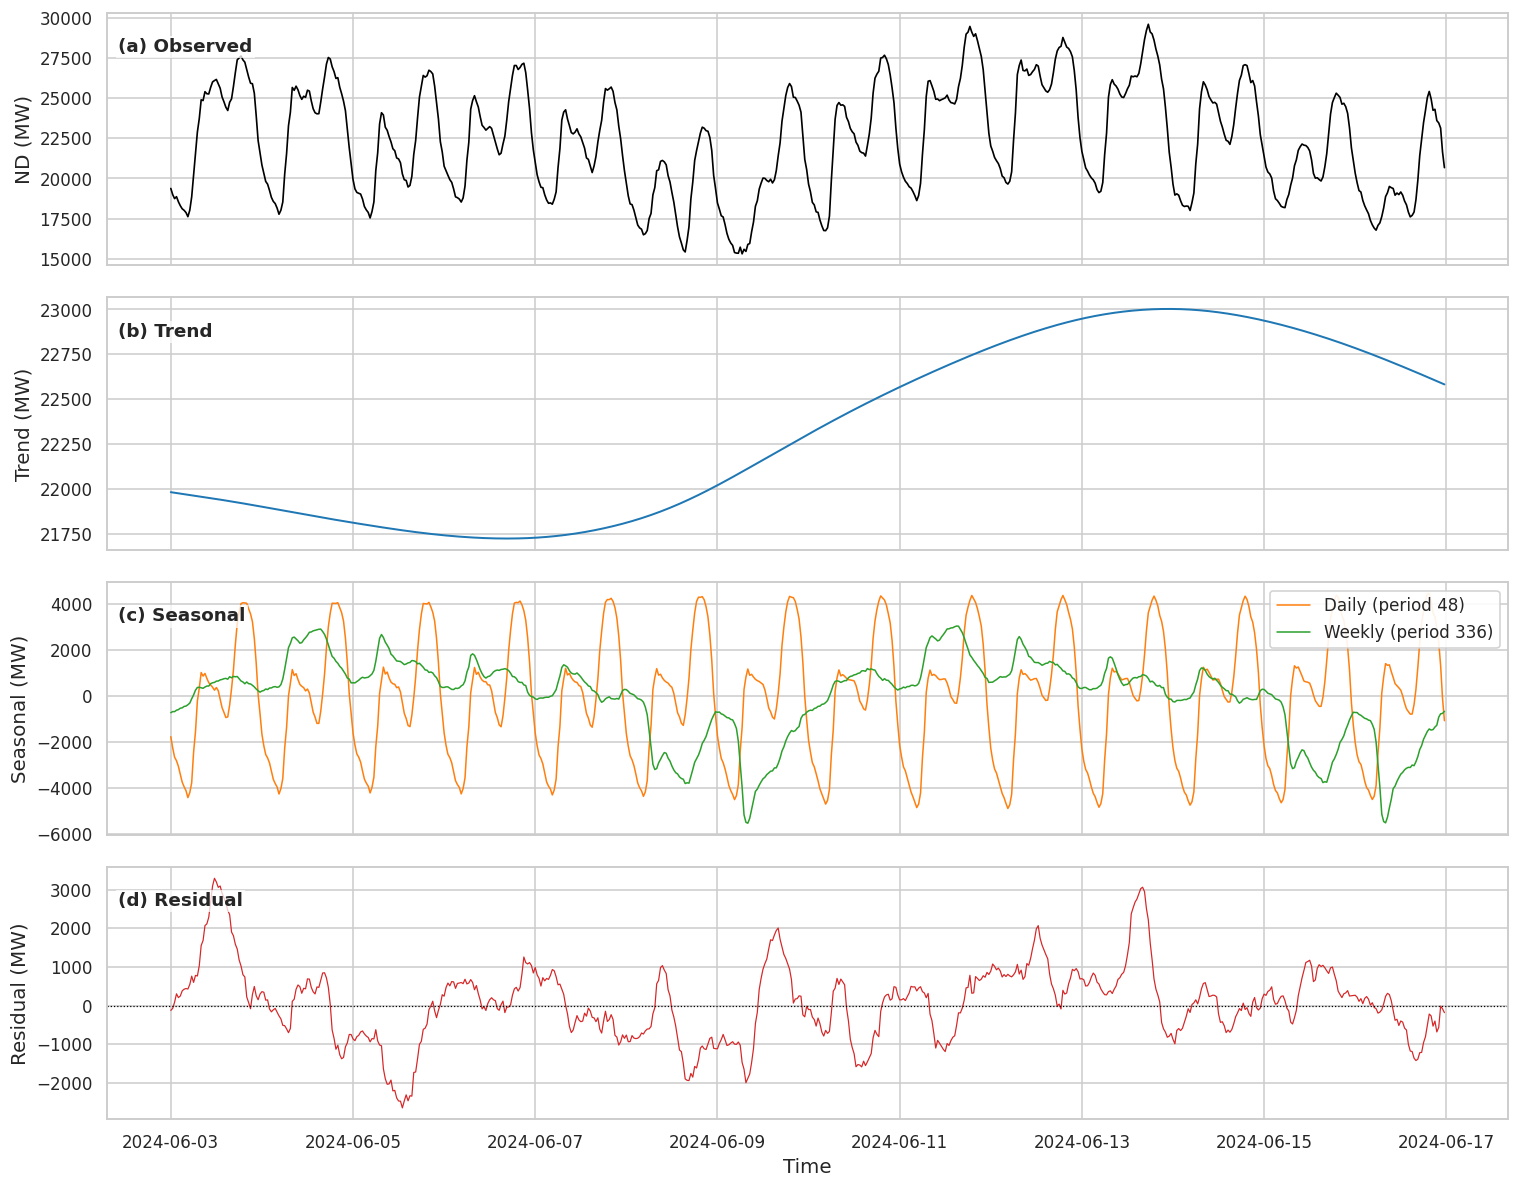

In [10]:
# ===== MSTL decomposition — HÌNH NÀY NHÚNG VÀO PAPER (mstl_decomposition.png) =====
# SỬA: bỏ title của từng subplot. main.tex đã có \caption giải thích đầy đủ bên dưới
# hình rồi, để thêm 4 dòng title in đậm nữa là dư thừa và làm rối hình.
# Thay bằng nhãn góc (a)/(b)/(c)/(d) — chuẩn hay dùng trong hình khoa học.
tuan_minh_hoa = thanh_phan.loc["2024-06-03":"2024-06-16"]

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
panel_labels = ["(a) Observed", "(b) Trend", "(c) Seasonal", "(d) Residual"]

axes[0].plot(df.loc[tuan_minh_hoa.index, "ND"], color="black", linewidth=1.1)
axes[0].set_ylabel("ND (MW)", fontsize=13)

axes[1].plot(tuan_minh_hoa["trend"], color="tab:blue", linewidth=1.3)
axes[1].set_ylabel("Trend (MW)", fontsize=13)

axes[2].plot(tuan_minh_hoa["seasonal_daily"], color="tab:orange", linewidth=1, label="Daily (period 48)")
axes[2].plot(tuan_minh_hoa["seasonal_weekly"], color="tab:green", linewidth=1, label="Weekly (period 336)")
axes[2].set_ylabel("Seasonal (MW)", fontsize=13)
axes[2].legend(loc="upper right", fontsize=11, framealpha=0.9)

axes[3].plot(tuan_minh_hoa["resid"], color="tab:red", linewidth=0.8)
axes[3].axhline(0, color="black", linewidth=0.8, linestyle=":")
axes[3].set_ylabel("Residual (MW)", fontsize=13)
axes[3].set_xlabel("Time", fontsize=13)

for ax, label in zip(axes, panel_labels):
    ax.text(0.008, 0.90, label, transform=ax.transAxes, fontsize=12,
            fontweight="bold", va="top", ha="left",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5))
    ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig("mstl_decomposition.png", dpi=300, bbox_inches="tight")   # MỚI: notebook gốc không lưu file nào
plt.show()

**Nhận xét**

Thành phần xu hướng biến động mượt mà và chậm rãi, phản ánh sự thay đổi nhu cầu điện nền qua từng tuần chứ không mang tính chu kỳ ngắn hạn. Thành phần mùa vụ ngày có biên độ dao động lớn hơn nhiều so với thành phần mùa vụ tuần và lặp lại hình dạng hai đỉnh cao điểm sáng và tối đã phát hiện ở phân tích song biến của notebook trước, trong khi thành phần mùa vụ tuần thể hiện rõ mức nền thấp hơn vào hai ngày cuối tuần so với năm ngày làm việc. Phần dư dao động quanh mức không mà không thể hiện quy luật lặp lại rõ ràng, cho thấy hai chu kỳ mùa vụ 48 và 336 đã giải thích được phần lớn cấu trúc có tính lặp lại của tín hiệu nhu cầu điện, phần biến động còn lại trong phần dư nhiều khả năng gắn với các yếu tố phi định kỳ như điều kiện thời tiết bất thường hoặc ngày lễ, đúng như đã lập luận trong bản đồ giả thuyết của notebook trước.

### 4.3 Định lượng tỷ trọng đóng góp của từng thành phần

In [11]:
phuong_sai_quan_trac = df["ND"].var()
phuong_sai_trend = thanh_phan["trend"].var()
phuong_sai_mua_ngay = thanh_phan["seasonal_daily"].var()
phuong_sai_mua_tuan = thanh_phan["seasonal_weekly"].var()
phuong_sai_du = thanh_phan["resid"].var()

bang_ty_trong = pd.DataFrame({
    "Thành phần": ["Xu hướng (Trend)", "Mùa vụ ngày (Seasonal Daily)", "Mùa vụ tuần (Seasonal Weekly)", "Phần dư (Residual)"],
    "Phương sai": [phuong_sai_trend, phuong_sai_mua_ngay, phuong_sai_mua_tuan, phuong_sai_du],
})
bang_ty_trong["Tỷ trọng so với phương sai quan trắc (%)"] = (bang_ty_trong["Phương sai"] / phuong_sai_quan_trac * 100).round(2)
bang_ty_trong

,Thành phần,Phương sai,Tỷ trọng so với phương sai quan trắc (%)
0,Xu hướng (Trend),"14,849,670.0102",38.4100
1,Mùa vụ ngày (Seasonal Daily),"18,735,349.8474",48.4600
2,Mùa vụ tuần (Seasonal Weekly),"3,107,374.7686",8.0400
3,Phần dư (Residual),"1,297,864.8695",3.3600


**Nhận xét**

Bảng định lượng xác nhận thành phần mùa vụ ngày chiếm tỷ trọng phương sai lớn nhất trong bốn thành phần, khẳng định lại bằng con số cụ thể phát hiện định tính đã nêu ở mục 4.2 rằng nhịp sinh hoạt trong ngày là yếu tố chi phối mạnh nhất đối với biến động nhu cầu điện. Thành phần mùa vụ tuần tuy có tỷ trọng nhỏ hơn nhưng vẫn đóng góp đáng kể, đủ để biện minh cho việc giữ lại đặc trưng ngày trong tuần và cờ cuối tuần trong tập đặc trưng mô hình theo đúng đề xuất ở Research Proposal. Tỷ trọng phần dư ở mức tương đối thấp cho thấy phần lớn tín hiệu có thể được giải thích bằng các quy luật tất định theo lịch, củng cố cơ sở cho hướng tiếp cận dự báo dựa trên đặc trưng thời gian tuần hoàn thay vì mô hình chuỗi thời gian tự hồi quy phức tạp.

# Part 5: Bản đồ tương quan đa biến

### 5.1 Ma trận tương quan giữa nhu cầu điện và các thuộc tính hệ thống

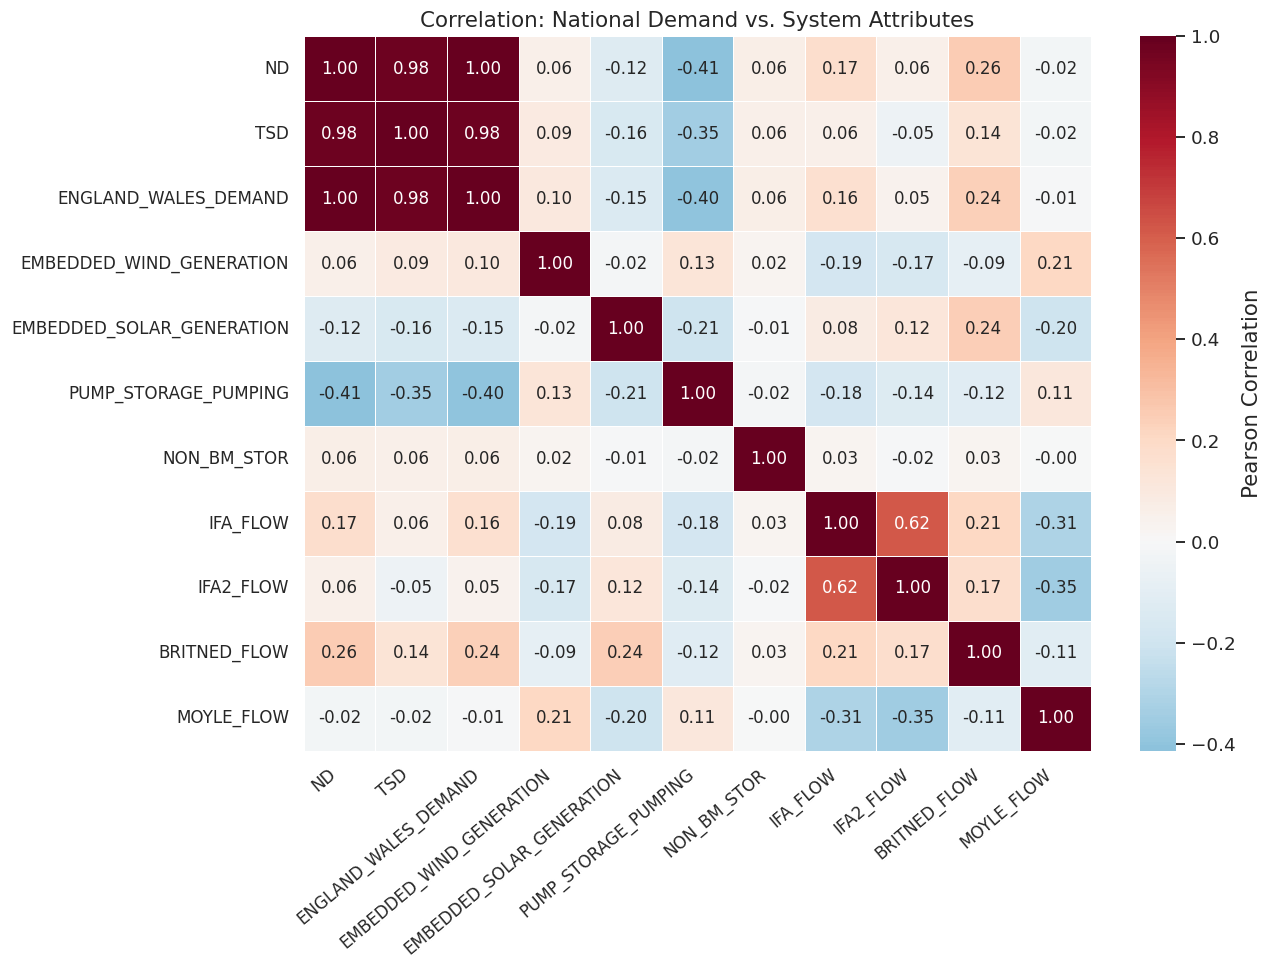

In [12]:
cot_tuong_quan = [
    "ND", "TSD", "ENGLAND_WALES_DEMAND",
    "EMBEDDED_WIND_GENERATION", "EMBEDDED_SOLAR_GENERATION",
    "PUMP_STORAGE_PUMPING", "NON_BM_STOR",
    "IFA_FLOW", "IFA2_FLOW", "BRITNED_FLOW", "MOYLE_FLOW",
]

ma_tran_tuong_quan = df[cot_tuong_quan].corr(method="pearson")

plt.figure(figsize=(12, 9))
sns.heatmap(ma_tran_tuong_quan, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, annot_kws={"size": 11},
            cbar_kws={"label": "Pearson Correlation"})
plt.title("Correlation: National Demand vs. System Attributes", fontsize=14)
plt.xticks(rotation=40, ha="right", fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

**Nhận xét**

Ma trận tương quan tiếp tục xác nhận ba cột nhu cầu lõi ND, TSD và ENGLAND_WALES_DEMAND tương quan gần như tuyệt đối với nhau, đúng như đã phát hiện ở notebook trước. Trong nhóm năng lượng tái tạo nhúng, sản lượng điện mặt trời thể hiện tương quan âm ở mức trung bình với ND, trong khi sản lượng điện gió thể hiện tương quan gần như bằng không hoặc dương rất yếu, một phát hiện nhất quán với kết quả kiểm định giả thuyết H5 đã trình bày trước đây. Đây là bằng chứng tương quan tuyến tính đồng thời tại cùng một thời điểm, tuy nhiên vì cả nhu cầu điện lẫn sản lượng tái tạo đều là chuỗi thời gian có quán tính, mối liên hệ thực sự giữa hai đại lượng này có thể xảy ra lệch pha theo thời gian, cần được khảo sát thêm bằng tương quan chéo ở mục 5.2.

### 5.2 Tương quan chéo giữa nhu cầu điện và năng lượng mặt trời nhúng

Hàm tương quan chéo, viết tắt CCF, đo mức độ tương quan giữa hai chuỗi khi một trong hai chuỗi được dịch chuyển tới hoặc lùi theo thời gian một số độ trễ nhất định, cho phép phát hiện mối quan hệ dạng dẫn dắt hoặc trễ pha mà tương quan tức thời ở mục 5.1 không thể hiện được.

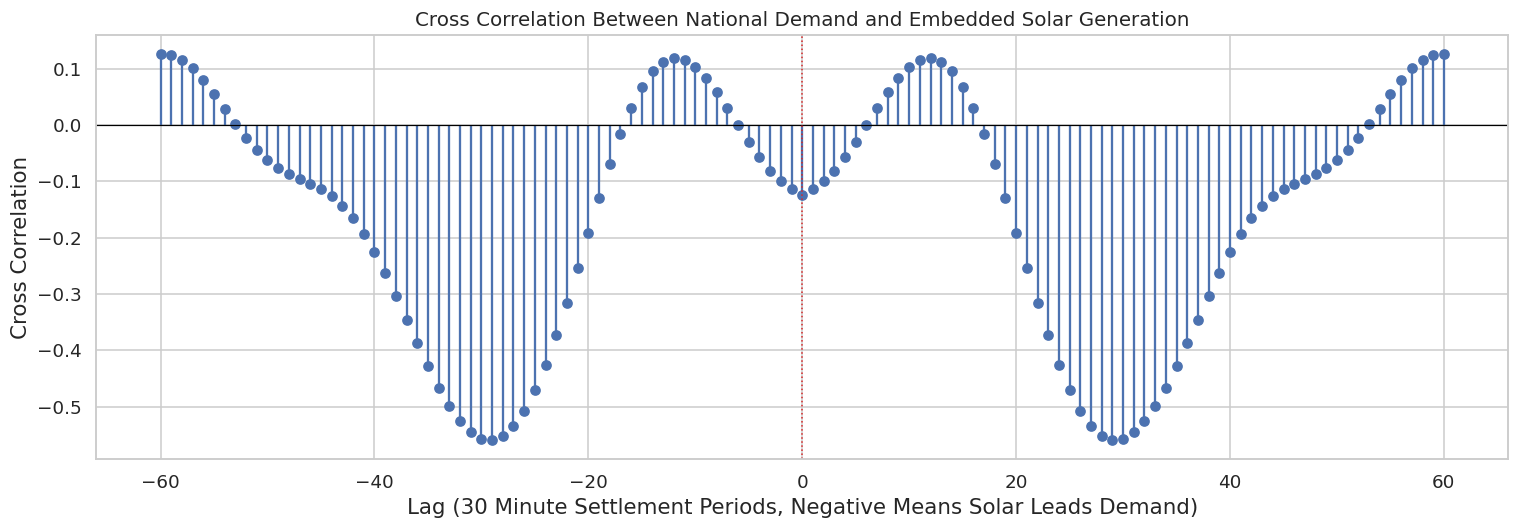

Độ trễ có tương quan mạnh nhất: -29 chu kỳ, giá trị tương quan: -0.5593


In [13]:
def tinh_tuong_quan_cheo(x, y, do_tre_toi_da):
    danh_sach_do_tre = list(range(-do_tre_toi_da, do_tre_toi_da + 1))
    danh_sach_gia_tri = []
    for do_tre in danh_sach_do_tre:
        if do_tre < 0:
            danh_sach_gia_tri.append(x.corr(y.shift(-do_tre)))
        else:
            danh_sach_gia_tri.append(x.corr(y.shift(do_tre)))
    return pd.Series(danh_sach_gia_tri, index=danh_sach_do_tre)

DO_TRE_TOI_DA = 60  # 30 giờ mỗi hướng

ccf_solar = tinh_tuong_quan_cheo(df["ND"], df["EMBEDDED_SOLAR_GENERATION"], DO_TRE_TOI_DA)

plt.figure(figsize=(14, 5))
plt.stem(ccf_solar.index, ccf_solar.values, basefmt=" ")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="tab:red", linestyle=":", linewidth=1)
plt.title("Cross Correlation Between National Demand and Embedded Solar Generation")
plt.xlabel("Lag (30 Minute Settlement Periods, Negative Means Solar Leads Demand)")
plt.ylabel("Cross Correlation")
plt.tight_layout()
plt.show()

do_tre_manh_nhat = ccf_solar.abs().idxmax()
print(f"Độ trễ có tương quan mạnh nhất: {do_tre_manh_nhat} chu kỳ, giá trị tương quan: {ccf_solar[do_tre_manh_nhat]:.4f}")

**Nhận xét**

Đồ thị tương quan chéo cho thấy mối liên hệ giữa sản lượng điện mặt trời nhúng và nhu cầu điện không đạt cực trị tại độ trễ bằng không, mà tại một độ trễ âm, tức sản lượng mặt trời dẫn dắt trước nhu cầu đo được trên lưới truyền tải. Hình dạng này phù hợp với cơ chế vận hành thực tế: sản lượng điện mặt trời tăng dần từ giữa buổi sáng, sớm hơn thời điểm nhu cầu ròng trên lưới truyền tải chạm đáy giữa ngày, bởi nhu cầu ròng chỉ giảm sau khi sản lượng mặt trời tích lũy đủ lớn để bù đắp đáng kể cho phụ tải tại chỗ. Phát hiện lệch pha này là căn cứ định lượng cho câu hỏi RQ4 của Research Proposal, gợi ý rằng nếu mô hình dự báo muốn khai thác tối đa thông tin từ năng lượng tái tạo nhúng, có thể cân nhắc thêm phiên bản trễ của biến sản lượng mặt trời bên cạnh giá trị tức thời đã liệt kê trong tập đặc trưng.

### 5.3 Tương quan chéo giữa nhu cầu điện và năng lượng gió nhúng

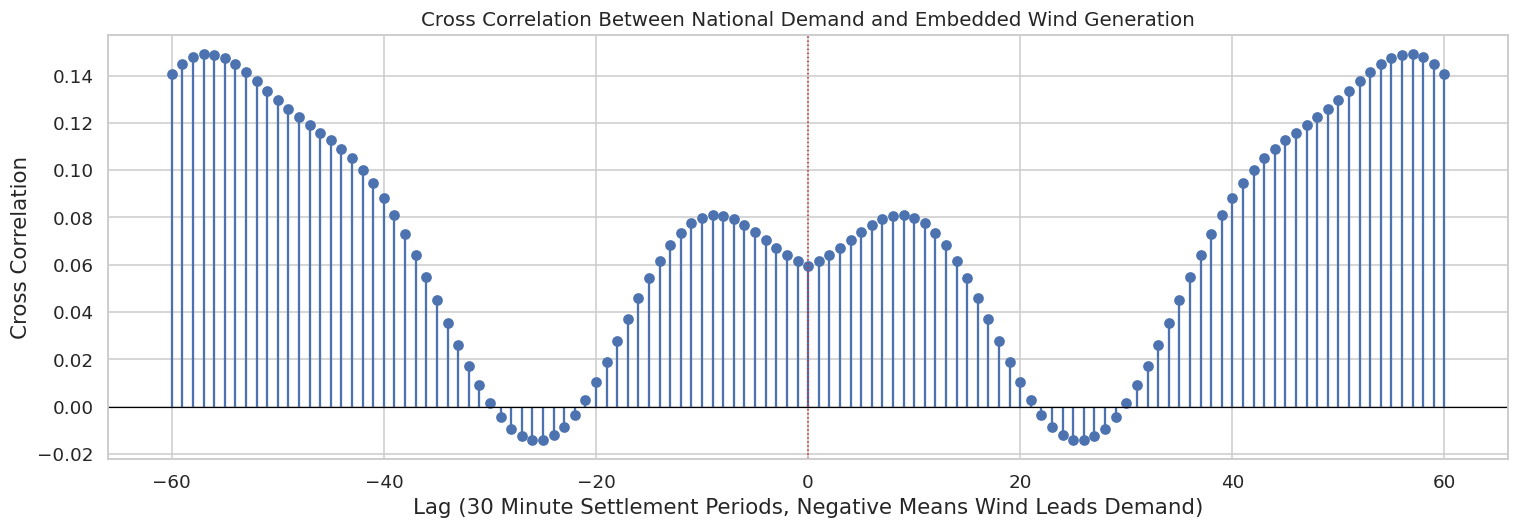

Độ trễ có tương quan mạnh nhất: -57 chu kỳ, giá trị tương quan: 0.1490


In [14]:
ccf_wind = tinh_tuong_quan_cheo(df["ND"], df["EMBEDDED_WIND_GENERATION"], DO_TRE_TOI_DA)

plt.figure(figsize=(14, 5))
plt.stem(ccf_wind.index, ccf_wind.values, basefmt=" ")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="tab:red", linestyle=":", linewidth=1)
plt.title("Cross Correlation Between National Demand and Embedded Wind Generation")
plt.xlabel("Lag (30 Minute Settlement Periods, Negative Means Wind Leads Demand)")
plt.ylabel("Cross Correlation")
plt.tight_layout()
plt.show()

do_tre_manh_nhat_gio = ccf_wind.abs().idxmax()
print(f"Độ trễ có tương quan mạnh nhất: {do_tre_manh_nhat_gio} chu kỳ, giá trị tương quan: {ccf_wind[do_tre_manh_nhat_gio]:.4f}")

**Nhận xét**

Khác với sản lượng điện mặt trời, tương quan chéo giữa sản lượng điện gió nhúng và nhu cầu điện duy trì biên độ thấp và tương đối bằng phẳng trên toàn bộ dải độ trễ được khảo sát, không thể hiện một đỉnh lệch pha rõ rệt như trường hợp điện mặt trời. Điều này phù hợp với bản chất vật lý của nguồn gió, vốn phụ thuộc vào điều kiện khí tượng biến đổi liên tục theo giờ và theo ngày mà không đồng bộ với chu kỳ ngày đêm của nhu cầu điện, khác hẳn với chu kỳ mặt trời vốn luôn gắn chặt với giờ trong ngày. Kết quả này củng cố khuyến nghị trong Research Proposal về việc đưa sản lượng điện gió và sản lượng điện mặt trời vào mô hình như hai đặc trưng tách biệt thay vì gộp chung thành một biến năng lượng tái tạo tổng hợp duy nhất.

### Tổng kết notebook

**Nhận xét kết luận**

Bốn bước phân tích thống kê trong notebook này cung cấp nền tảng toán học vững chắc cho các quyết định thiết kế mô hình đã đề xuất trong đề xuất nghiên cứu. Kiểm định Augmented Dickey Fuller xác nhận chuỗi nhu cầu điện dừng ở mức gốc, cho phép sử dụng trực tiếp đơn vị MW làm biến mục tiêu mà không cần biến đổi sai phân. Phân tích ACF và PACF xác định rõ hai chu kỳ mùa vụ chi phối chuỗi là chu kỳ ngày với độ dài 48 chu kỳ quyết toán và chu kỳ tuần với độ dài 336 chu kỳ quyết toán, đồng thời cho thấy quán tính tự hồi quy tập trung chủ yếu ở vài độ trễ đầu tiên; hai độ trễ 48 và 336 này chính là công thức toán học của hai đường cơ sở **SNaive Daily** ($\hat{Y}_t = Y_{t-48}$) và **SNaive Weekly** ($\hat{Y}_t = Y_{t-336}$) sẽ được tính toán và đối chiếu với Linear Regression, Random Forest, XGBoost và LightGBM ở notebook 04, thay thế cho đường cơ sở trung bình gộp (Average Model) của phiên bản đề xuất trước đây. Phân rã MSTL định lượng hóa tỷ trọng đóng góp của từng thành phần, khẳng định mùa vụ ngày là yếu tố chi phối mạnh nhất, tiếp theo là mùa vụ tuần, trong khi phần dư chiếm tỷ trọng khiêm tốn — một gợi ý định tính rằng SNaive Daily nhiều khả năng sẽ cho sai số thấp hơn SNaive Weekly, điều sẽ được kiểm định chính thức bằng giả thuyết H1a ở notebook huấn luyện mô hình. Phân tích tương quan chéo đa biến phát hiện sản lượng điện mặt trời nhúng dẫn dắt trước nhu cầu điện theo một độ trễ nhất định, trong khi sản lượng điện gió nhúng không thể hiện quy luật lệch pha rõ rệt tương tự. Toàn bộ các phát hiện này sẽ được sử dụng làm căn cứ định lượng khi hoàn thiện tập đặc trưng và lựa chọn mô hình ở notebook xây dựng đặc trưng và huấn luyện mô hình tiếp theo.
